In [43]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import datetime

Last fuel report fs01:  2026-08-26 23:03:07.881 Last fuel report fs02:  2026-08-18 18:05:10.107
No hay reporte de combustible desde el 26-08-2026.

Chart of values: This part of the notebook is for troubleshooting and graphical analysis.

In [44]:
#raw_fuel_data=pd.read_csv(r'C:\Users\Jose.Hurtado\Documents\Zonar_projects\data\zonar\Export.xlsx - Sheet1.csv',sep=',',encoding='latin1')
raw_fuel_data=pd.read_excel(r'C:\Users\Jose.Hurtado\Documents\Zonar_projects\data\mym\bxh-885.xlsx') #excel
raw_fuel_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 9332 entries, 0 to 9331
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   Created  9332 non-null   str  
 1   Message  9332 non-null   str  
 2   Status   9332 non-null   str  
dtypes: str(3)
memory usage: 218.8 KB


In [45]:
e0x=raw_fuel_data[raw_fuel_data['Status'].str.contains('3E0')]
row_number=e0x.shape[0]
#e0x.to_csv('/home/jlhb1984/py-projects/data/veepo/wcr728_.csv')

In [46]:
#I must deleted 3 last elements of the messahe because of an error that mix fuel sensor 1 with fuel sensor 2.
fs01_dec_value=[]
fs02_dec_value=[]
last_index_fs01=[]
last_index_fs02=[]
date_fs01_dec_value=[]
fs01_raw_data=[]
date_fs02_dec_value=[]
fs02_raw_data=[]
values_dates_fs01=pd.DataFrame()
values_dates_fs02=pd.DataFrame()

for i in range(0,row_number):
    e0x_aux=e0x.iloc[i,2]
    aux=e0x_aux.find('3E01')
    #print(aux)
    if aux>=100:
        if len(e0x_aux)>0:
            fs01=(e0x_aux[aux:aux+72])            
            if len(fs01)>17:
                msb=fs01[10:12]
                lsb=fs01[8:10]
                measure=msb+lsb                
                try:
                    fs01_dec_value.append(int(measure,16))
                    date_fs01_dec_value.append(e0x.iloc[i,0])            
                    fs01_raw_data.append(e0x.iloc[i,2])
                except:
                    pass
            if fs01[18:22]=='3E01':
                msb=fs01[28:30]
                lsb=fs01[26:28]
                measure=msb+lsb
                try:
                    fs01_dec_value.append(int(measure,16))
                    date_fs01_dec_value.append(e0x.iloc[i,0])            
                    fs01_raw_data.append(e0x.iloc[i,2])
                except:
                    pass
            if fs01[36:40]=='3E01':
                msb=fs01[46:48]
                lsb=fs01[44:46]
                measure=msb+lsb
                try:
                    fs01_dec_value.append(int(measure,16))
                    date_fs01_dec_value.append(e0x.iloc[i,0])            
                    fs01_raw_data.append(e0x.iloc[i,2])
                except:
                    pass
            if fs01[58:64]=='3E01':
                msb=fs01[64:66]
                lsb=fs01[62:64]
                measure=msb+lsb
                try:
                    fs01_dec_value.append(int(measure,16))
                    date_fs01_dec_value.append(e0x.iloc[i,0])            
                    fs01_raw_data.append(e0x.iloc[i,2])
                except:
                    pass

for i in range(0,row_number):
    e0x_aux=e0x.iloc[i,2]
    aux=e0x_aux.find('3E02')
    if aux>100:
        if len(e0x_aux)>0:
            fs02=(e0x_aux[aux:aux+72])
            if len(fs02)>17:
                msb=fs02[10:12]
                lsb=fs02[8:10]
                measure=msb+lsb
                try:
                    fs02_dec_value.append(int(measure,16))
                    date_fs02_dec_value.append(e0x.iloc[i,0])
                    fs02_raw_data.append(e0x.iloc[i,2])
                except:
                    pass
            if fs02[18:22]=='3E02':
                msb=fs02[28:30]
                lsb=fs02[26:28]
                measure=msb+lsb
                try:
                    fs02_dec_value.append(int(measure,16))
                    date_fs02_dec_value.append(e0x.iloc[i,0])            
                    fs02_raw_data.append(e0x.iloc[i,2])
                except:
                    pass
            if fs02[36:40]=='3E02':
                msb=fs02[46:48]
                lsb=fs02[44:46]
                measure=msb+lsb
                try:
                    fs02_dec_value.append(int(measure,16))
                    date_fs02_dec_value.append(e0x.iloc[i,0])
                    fs02_raw_data.append(e0x.iloc[i,2])
                except:
                    pass            
            if fs02[58:64]=='3E02':
                msb=fs02[64:66]
                lsb=fs02[62:64]
                measure=msb+lsb
                try:
                    fs02_dec_value.append(int(measure,16))
                    date_fs02_dec_value.append(e0x.iloc[i,0])            
                    fs02_raw_data.append(e0x.iloc[i,2])
                except:
                    pass              

fs01_count=len(fs01_dec_value)
fs02_count=len(fs02_dec_value)

print('fs01_dec_value',len(fs01_dec_value),'date_fs02_dec_value',len(date_fs02_dec_value))
values_dates_fs01['Value fs01']=fs01_dec_value
values_dates_fs01['Dates fs01']=date_fs01_dec_value
values_dates_fs01['raw data']=fs01_raw_data
values_dates_fs02['Value fs02']=fs02_dec_value
values_dates_fs02['Dates fs02']=date_fs02_dec_value
values_dates_fs02['raw data']=fs02_raw_data

print("Last fuel report fs01: ",values_dates_fs01.iloc[fs01_count-1,1],"Last fuel report fs02: ",values_dates_fs02.iloc[fs02_count-1,1])        


fs01_dec_value 8619 date_fs02_dec_value 6454
Last fuel report fs01:  2026-08-26 23:03:07.881 Last fuel report fs02:  2026-08-26 23:03:07.881


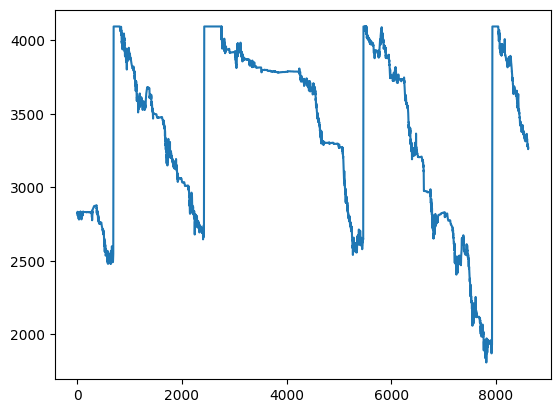

In [47]:
fs01_x_values=[]
fs02_x_values=[]

for i in range(0,fs01_count):
    fs01_x_values.append(i)
    
for i in range(0,fs02_count):
    fs02_x_values.append(i)

plt.plot(fs01_x_values,fs01_dec_value)
#plt.plot(fs02_x_values,fs02_dec_value)

In [48]:
for i in range(0,values_dates_fs01.shape[0]):
    aux_date=int(values_dates_fs01.iloc[i,2][36:44],16)
    print(i,values_dates_fs01.iloc[i,0],datetime.datetime.fromtimestamp(int(aux_date)))

0 2828 2026-07-31 19:00:43
1 2829 2026-07-31 19:00:43
2 2830 2026-07-31 19:03:23
3 2830 2026-07-31 19:03:23
4 2831 2026-07-31 19:06:03
5 2832 2026-07-31 19:06:03
6 2833 2026-07-31 19:08:43
7 2834 2026-07-31 19:08:43
8 2808 2026-07-31 19:11:23
9 2828 2026-07-31 19:11:23
10 2829 2026-07-31 19:14:03
11 2824 2026-07-31 19:14:03
12 2824 2026-07-31 19:16:43
13 2824 2026-07-31 19:16:43
14 2824 2026-07-31 19:19:23
15 2820 2026-07-31 19:19:23
16 2820 2026-07-31 19:22:03
17 2820 2026-07-31 19:22:03
18 2818 2026-07-31 19:24:43
19 2816 2026-07-31 19:24:43
20 2814 2026-07-31 19:27:23
21 2811 2026-07-31 19:27:23
22 2810 2026-07-31 19:30:03
23 2811 2026-07-31 19:30:03
24 2810 2026-07-31 19:32:43
25 2811 2026-07-31 19:32:43
26 2802 2026-07-31 19:35:23
27 2795 2026-07-31 19:35:23
28 2793 2026-07-31 19:38:03
29 2785 2026-07-31 19:38:03
30 2800 2026-07-31 19:40:43
31 2788 2026-07-31 19:40:43
32 2795 2026-07-31 19:43:23
33 2781 2026-07-31 19:43:23
34 2789 2026-07-31 19:46:03
35 2790 2026-07-31 19:46:03
36

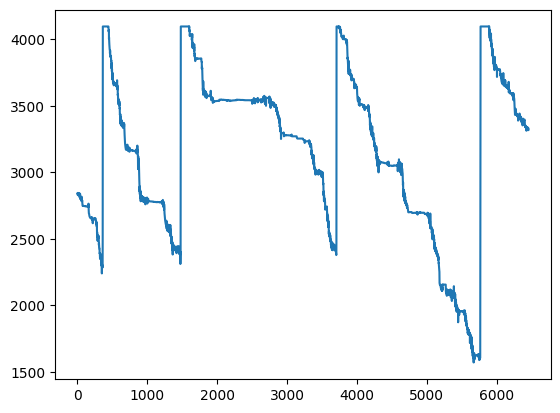

In [49]:
plt.plot(fs02_x_values,fs02_dec_value)
#plt.plot(fs02_x_values,fs02_dec_value)

In [50]:
for i in range(0,values_dates_fs02.shape[0]):
    aux_date=int(values_dates_fs02.iloc[i,2][36:44],16)
    print(i,values_dates_fs02.iloc[i,0],datetime.datetime.fromtimestamp(int(aux_date)))

0 2840 2026-07-31 19:00:43
1 2838 2026-07-31 19:00:43
2 2836 2026-07-31 19:03:23
3 2834 2026-07-31 19:03:23
4 2833 2026-07-31 19:06:03
5 2831 2026-07-31 19:06:03
6 2830 2026-07-31 19:08:43
7 2828 2026-07-31 19:08:43
8 2845 2026-07-31 19:11:23
9 2829 2026-07-31 19:11:23
10 2833 2026-07-31 19:14:03
11 2831 2026-07-31 19:14:03
12 2832 2026-07-31 19:16:43
13 2832 2026-07-31 19:16:43
14 2832 2026-07-31 19:19:23
15 2835 2026-07-31 19:19:23
16 2835 2026-07-31 19:22:03
17 2835 2026-07-31 19:22:03
18 2835 2026-07-31 19:24:43
19 2835 2026-07-31 19:24:43
20 2835 2026-07-31 19:27:23
21 2835 2026-07-31 19:27:23
22 2835 2026-07-31 19:30:03
23 2835 2026-07-31 19:30:03
24 2835 2026-07-31 19:32:43
25 2835 2026-07-31 19:32:43
26 2844 2026-07-31 19:35:23
27 2837 2026-07-31 19:35:23
28 2833 2026-07-31 19:38:03
29 2832 2026-07-31 19:38:03
30 2827 2026-07-31 19:40:43
31 2822 2026-07-31 19:40:43
32 2812 2026-07-31 19:43:23
33 2830 2026-07-31 19:43:23
34 2826 2026-07-31 19:46:03
35 2826 2026-07-31 19:46:03
36

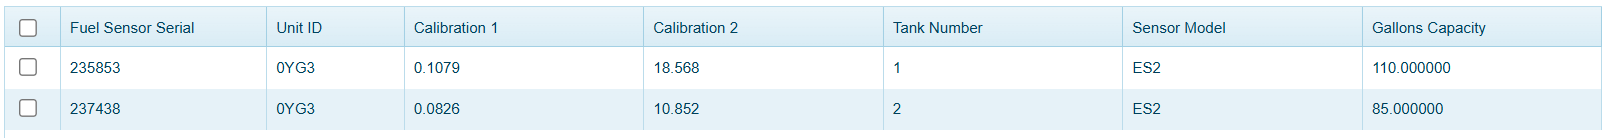

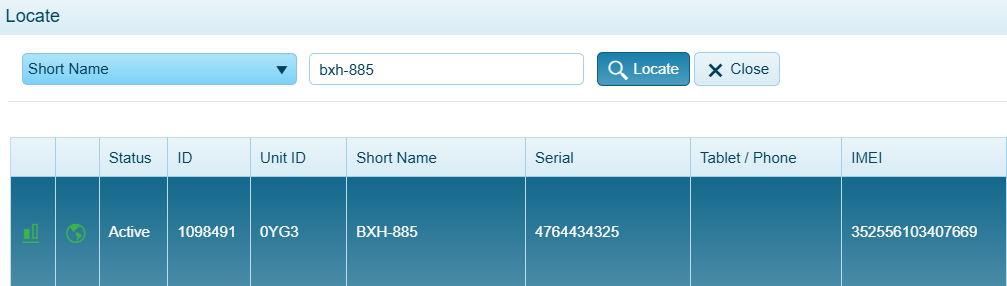

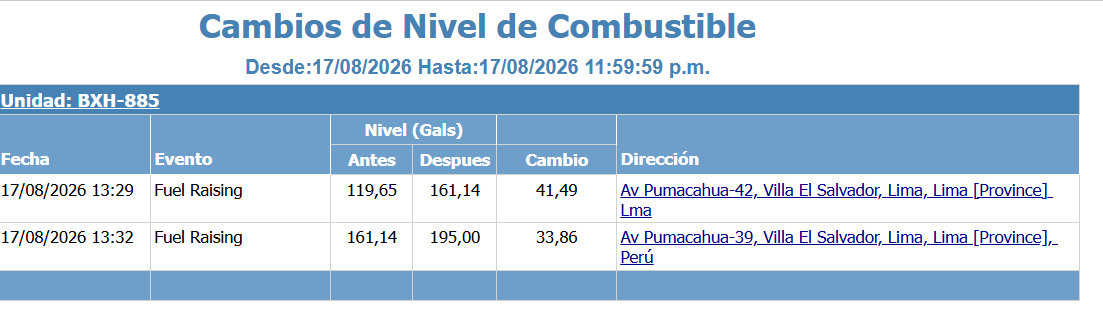

In [51]:
"""
7929 3253 2026-08-21 17:22:25
7930 4095 2026-08-21 17:22:25
"""
x=[]
y=[]
for i in range(0,2):
    x.append(int(input("Enter the initial ncode for prediction: ")))

for i in range(0,2):
    y.append(0.1079*x[i]-18.568)
print("Differences:",y[1]/3.785412,'-',y[0]/3.785412,':',y[1]/3.785412-y[0]/3.785412,'gallons')

Differences: 111.8194003717429 - 87.8188952748076 : 24.0005050969353 gallons


In [52]:
"""
3707 2475 2026-08-17 13:29:34
3708 4095 2026-08-17 13:32:14
"""
x=[]
y=[]
for i in range(0,2):
    x.append(int(input("Enter the initial ncode for prediction: ")))

for i in range(0,2):
    y.append(0.0826*x[i]-18.568)
print("Differences:",y[1]/3.785412,'-',y[0]/3.785412,':',y[1]/3.785412-y[0]/3.785412,'gallons')

Differences: 84.45025270697087 - 49.100864053899556 : 35.349388653071316 gallons
